In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [20]:
#using cell one and two to from question 2 here
x = np.linspace(0, 10, 20)

y = 2 * x + 3

sigma = np.linspace(2, 0.2, len(x))

noise = np.random.normal(0, sigma)

y_scatter = y + noise

In [21]:
#removes the the first data point from each array
x_fit_data = x[1:]
y_fit_data = y_scatter[1:]
sigma_fit_data = sigma[1:]

In [22]:
#the expressions the problem asks for
def exp_model(x, a, b):
    return a * np.exp(-b * x)

def power_model(x, a, b):
    return a / (x ** b)

In [23]:
# here we are trying to find values so that the curve matches the data points over and over again
exp_fit, exp_cov = curve_fit(exp_model, x_fit_data, y_fit_data)
# and we are storing the values we get to "fit" for both models
power_fit, power_cov = curve_fit(power_model, x_fit_data, y_fit_data)

In [24]:
print(f"Exponential fit: a = {exp_fit[0]:.4f}, b = {exp_fit[1]:.4f}")
#writng out the values we got for in string 
print(f"Power fit: a = {power_fit[0]:.4f}, b = {power_fit[1]:.4f}")

Exponential fit: a = 5.9617, b = -0.1410
Power fit: a = 4.2232, b = -0.7208


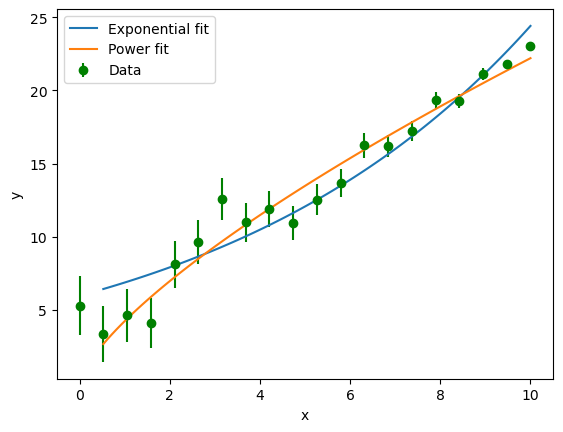

In [25]:
#makes the spacing out 100 evenly spaced from the smallest and biggest x values
x_smooth = np.linspace(min(x_fit_data), max(x_fit_data), 100)
# the orignal noisy plot from question 2
plt.errorbar(x, y_scatter, yerr=sigma, fmt='o', color='green', label='Data')
#plots out the exponential fitted curve
plt.plot(x_smooth, exp_model(x_smooth, exp_fit[0], exp_fit[1]), label='Exponential fit')
# now does the the power fitted curve
plt.plot(x_smooth, power_model(x_smooth, power_fit[0], power_fit[1]), label='Power fit')

#labeling
plt.xlabel("x")
plt.ylabel("y")

plt.legend()

plt.savefig("best_fit_models.pdf")

plt.show()